# Variação dos Preços de Combustíveis no Brasil (2015–2024)

**Projeto G1 — Linguagem de Programação: Análise e Visualização de Dados com Python**
Autor: Natan Braslavsky

| Entrega | Link |
|---|---|
| Repositório | https://github.com/NatanBraslavsky/variacao-preco-combustivel |
| Página do projeto | https://natanbraslavsky.github.io/variacao-preco-combustivel/ |
| Dashboard | ver README |

---
## 1. Introdução

Os combustíveis estão na base de praticamente toda a cadeia econômica: transporte de cargas e
passageiros, logística, produção agrícola e custo de vida das famílias. Variações no preço da
gasolina, do diesel, do etanol, do GNV e do gás de cozinha (GLP) se propagam para o restante da
economia e podem ser muito diferentes entre estados e regiões.

Este notebook investiga a evolução desses preços entre **2015 e 2024**, buscando responder às
perguntas orientadoras do projeto:

1. Quais estados possuem combustíveis mais caros?
2. Qual combustível apresentou maior aumento?
3. Existem diferenças regionais relevantes?
4. Há períodos de maior instabilidade?
5. Como os preços evoluíram ao longo do tempo?
6. Existe relação entre inflação e combustíveis?
7. Quais combustíveis possuem maior volatilidade?

## 2. Contextualização econômica

No Brasil, o preço na bomba é formado por:

- **Preço de realização da Petrobras** — desde 2016 acompanha o mercado internacional (petróleo Brent + câmbio);
- **Tributos federais** (PIS/Cofins, Cide) e **estaduais** (ICMS, com alíquotas diferentes por UF);
- **Custo do etanol anidro** misturado à gasolina;
- **Margens de distribuição e revenda**, que variam com logística e concorrência local.

Por isso, na economia real, espera-se: (a) correlação positiva entre petróleo e preço,
(b) diferenças regionais persistentes (frete e ICMS) e (c) picos em choques como 2021–2022
(retomada pós-pandemia e guerra na Ucrânia). Este notebook verifica se a base fornecida
reproduz esses comportamentos.

## 3. Explicação da base de dados

Arquivo: `dados/simulacao_precos_combustiveis_brasil.csv` — base **simulada** disponibilizada pelo
professor ([repositório](https://github.com/AlexandreLouzada/Dados-Simulados-G1)).
4.440 linhas × 14 colunas.

| Coluna | Descrição |
|---|---|
| `ano`, `mes`, `data` | Período de referência (mensal) |
| `regiao`, `uf` | Região e estado |
| `combustivel` | Gasolina, Etanol, Diesel, GNV ou GLP |
| `preco_medio`, `preco_minimo`, `preco_maximo` | Preços por unidade (R$) |
| `variacao_mensal` | Variação percentual em relação ao mês anterior |
| `inflacao` | Índice de inflação (% a.a.) |
| `cotacao_petroleo` | Cotação internacional do barril (US$) |
| `consumo_estimado` | Consumo estimado no mês |
| `nivel_preco` | Classificação: Baixo, Médio, Alto, Crítico |

Além do CSV, o projeto integra uma **fonte externa real**: o IPCA acumulado em 12 meses
(série 13522 do SGS/Banco Central), obtido via API com `requests`.

## 4. Leitura dos dados

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

from src import dados as D
from src.api_bcb import obter_ipca
from src.banco import obter_engine, construir_banco, contar_registros, executar_consulta, CONSULTAS

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

IMG = RAIZ / "imagens"
IMG.mkdir(exist_ok=True)

CORES = {"Gasolina": "#2a78d6", "Etanol": "#eb6834", "Diesel": "#1baf7a", "GNV": "#eda100", "GLP": "#e87ba4"}
AZUL, LARANJA, CINZA = "#2a78d6", "#eb6834", "#898781"
sns.set_theme(style="whitegrid", rc={
    "font.family": ["Segoe UI", "DejaVu Sans"],
    "axes.edgecolor": "#c3c2b7", "grid.color": "#e1e0d9", "axes.titleweight": "semibold",
    "axes.titlesize": 13, "axes.titlelocation": "left", "figure.dpi": 110, "savefig.dpi": 150,
    "axes.spines.top": False, "axes.spines.right": False,
})

def salvar(fig, nome):
    fig.savefig(IMG / nome, bbox_inches="tight", facecolor="white")

bruto = D.carregar_bruto(RAIZ / "dados" / "simulacao_precos_combustiveis_brasil.csv")
print(bruto.shape)
bruto.head()

(4440, 14)


,ano,mes,data,regiao,uf,combustivel,preco_medio,preco_minimo,preco_maximo,variacao_mensal,inflacao,cotacao_petroleo,consumo_estimado,nivel_preco
0,2015,1,2015-01-01,Norte,AM,Gasolina,7.490,6.900,8.470,6.750,2.890,78.310,179221,Médio
1,2015,1,2015-01-01,Norte,PA,Diesel,3.800,3.500,4.300,1.670,10.940,95.350,50575,Alto
2,2015,1,2015-01-01,Norte,PA,GNV,4.830,4.450,5.460,-2.850,2.600,47.820,171715,Médio
3,2015,1,2015-01-01,Norte,RO,Gasolina,7.140,6.570,8.070,-4.830,6.990,95.940,195652,Crítico
4,2015,1,2015-01-01,Norte,TO,Diesel,3.300,3.030,3.730,6.300,3.020,45.920,49432,Médio


In [2]:
bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ano               4440 non-null   int64  
 1   mes               4440 non-null   int64  
 2   data              4440 non-null   str    
 3   regiao            4440 non-null   str    
 4   uf                4440 non-null   str    
 5   combustivel       4440 non-null   str    
 6   preco_medio       4440 non-null   float64
 7   preco_minimo      4440 non-null   float64
 8   preco_maximo      4440 non-null   float64
 9   variacao_mensal   4440 non-null   float64
 10  inflacao          4440 non-null   float64
 11  cotacao_petroleo  4440 non-null   float64
 12  consumo_estimado  4440 non-null   int64  
 13  nivel_preco       4440 non-null   str    
dtypes: float64(6), int64(3), str(5)
memory usage: 615.3 KB


In [3]:
bruto.describe().T

,count,mean,std,min,25%,50%,75%,max
ano,"4,440.000","2,019.500",2.873,"2,015.000","2,017.000","2,019.500","2,022.000","2,024.000"
mes,"4,440.000",6.500,3.452,1.000,3.750,6.500,9.250,12.000
preco_medio,"4,440.000",5.514,1.461,3.000,4.240,5.530,6.780,8.000
preco_minimo,"4,440.000",5.073,1.344,2.760,3.900,5.085,6.240,7.360
preco_maximo,"4,440.000",6.230,1.651,3.390,4.790,6.245,7.662,9.040
variacao_mensal,"4,440.000",0.510,4.019,-15.610,-2.130,0.500,3.212,14.730
inflacao,"4,440.000",7.016,2.877,2.000,4.510,7.010,9.480,12.000
cotacao_petroleo,"4,440.000",77.402,18.872,45.010,61.100,77.760,93.515,109.980
consumo_estimado,"4,440.000","126,397.951","71,390.339","5,013.000","63,811.500","125,770.000","187,888.500","249,977.000"


## 5. Limpeza e preparação

Verificações realizadas, uma a uma:

In [4]:
print("Colunas ausentes:", D.validar_colunas(bruto) or "nenhuma")
print("Valores nulos por coluna:", int(bruto.isna().sum().sum()))
print("Linhas totalmente duplicadas:", bruto.duplicated().sum())
print("Duplicatas na chave (data, uf, combustivel):", bruto.duplicated(D.CHAVE).sum())
print("Categorias:")
for c in ["regiao", "uf", "combustivel", "nivel_preco"]:
    print(f"  {c:12s}", sorted(bruto[c].unique()))

Colunas ausentes: nenhuma
Valores nulos por coluna: 0
Linhas totalmente duplicadas: 0
Duplicatas na chave (data, uf, combustivel): 503
Categorias:
  regiao       ['Centro-Oeste', 'Nordeste', 'Norte', 'Sudeste', 'Sul']
  uf           ['AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PR', 'RJ', 'RO', 'RS', 'SC', 'SP', 'TO']
  combustivel  ['Diesel', 'Etanol', 'GLP', 'GNV', 'Gasolina']
  nivel_preco  ['Alto', 'Baixo', 'Crítico', 'Médio']


**Achado 1 — duplicatas de chave.** Não há linhas idênticas, mas **503 registros** repetem o
mesmo trio *(mês, UF, combustível)* com valores diferentes. Exemplo:

In [5]:
dup = bruto[bruto.duplicated(D.CHAVE, keep=False)].sort_values(D.CHAVE)
dup.head(6)

,ano,mes,data,regiao,uf,combustivel,preco_medio,preco_minimo,preco_maximo,variacao_mensal,inflacao,cotacao_petroleo,consumo_estimado,nivel_preco
25,2015,1,2015-01-01,Sudeste,MG,Diesel,4.030,3.710,4.550,-4.060,10.940,48.800,50878,Alto
26,2015,1,2015-01-01,Sudeste,MG,Diesel,7.420,6.830,8.390,1.260,3.540,72.920,129817,Médio
35,2015,1,2015-01-01,Sul,RS,GNV,3.350,3.090,3.790,-1.770,11.980,77.500,32495,Médio
36,2015,1,2015-01-01,Sul,RS,GNV,6.870,6.320,7.760,2.050,5.470,55.600,202340,Alto
33,2015,1,2015-01-01,Sul,SC,GNV,5.170,4.760,5.850,2.800,2.320,100.960,237557,Médio
34,2015,1,2015-01-01,Sul,SC,GNV,3.310,3.040,3.740,1.620,5.640,102.260,194104,Baixo


Como representam a mesma observação, foram **consolidadas pela média** dos campos numéricos
(e pela moda do `nivel_preco`).

**Achado 2 — consistência dos preços.** Verificamos se `preco_minimo ≤ preco_medio ≤ preco_maximo`
e se cada UF pertence a uma única região:

In [6]:
ok_precos = ((bruto.preco_minimo <= bruto.preco_medio) & (bruto.preco_medio <= bruto.preco_maximo)).all()
print("Ordem mínimo ≤ médio ≤ máximo respeitada:", ok_precos)
print("UFs com mais de uma região:", (bruto.groupby("uf").regiao.nunique() > 1).sum())
print("Ano/mês coerentes com a data:",
      (pd.to_datetime(bruto.data).dt.year.eq(bruto.ano) & pd.to_datetime(bruto.data).dt.month.eq(bruto.mes)).all())

Ordem mínimo ≤ médio ≤ máximo respeitada: True
UFs com mais de uma região: 0
Ano/mês coerentes com a data: True


**Achado 3 — amostragem desigual.** Cada mês tem apenas 37 registros (de 100 combinações possíveis
UF × combustível) e alguns estados aparecem o dobro de vezes:

In [7]:
print("Registros por mês:", bruto.groupby("data").size().unique())
bruto.uf.value_counts().to_frame("registros").T

Registros por mês: [37]


uf,RJ,SP,MG,ES,PA,BA,PE,CE,GO,PR,SC,RS,AM,RO,TO,MA,PB,DF,MT,MS
registros,480,360,360,360,240,240,240,240,240,240,240,240,120,120,120,120,120,120,120,120


**Achado 4 — `nivel_preco` não acompanha o preço.** Se a classificação fosse coerente, o preço
médio cresceria de *Baixo* para *Crítico*. Não é o que acontece:

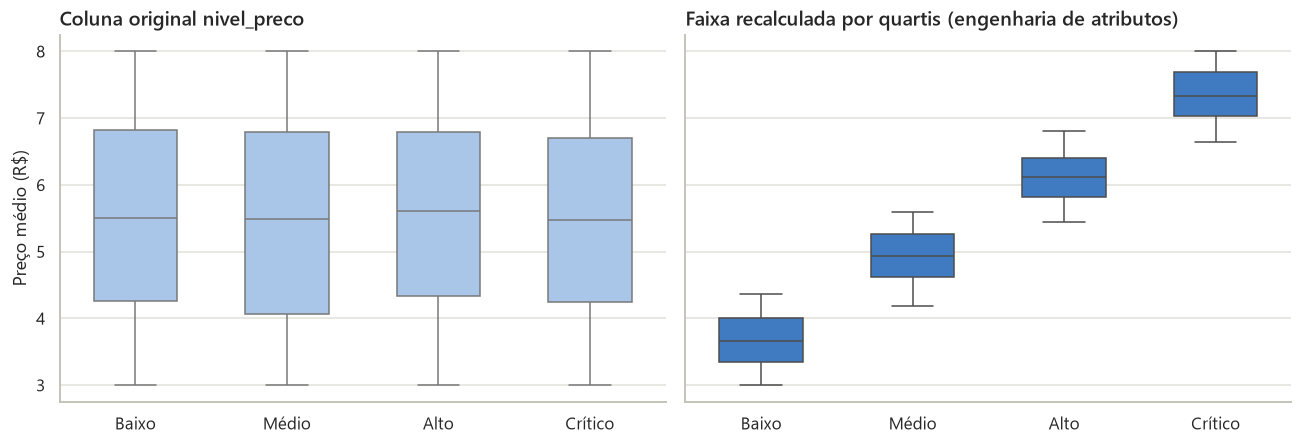

,min,mean,max
nivel_preco,,,
Baixo,3.000,5.515,8.000
Médio,3.010,5.472,8.000
Alto,3.000,5.582,8.000
Crítico,3.010,5.485,8.000


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
ordem = D.ORDEM_NIVEIS
sns.boxplot(bruto, x="nivel_preco", y="preco_medio", order=ordem, color="#9ec5f4", ax=axes[0], width=.55)
axes[0].set(title="Coluna original nivel_preco", xlabel="", ylabel="Preço médio (R$)")

tmp = D.criar_atributos(D.limpar(bruto))
sns.boxplot(tmp, x="faixa_preco", y="preco_medio", order=ordem, color=AZUL, ax=axes[1], width=.55)
axes[1].set(title="Faixa recalculada por quartis (engenharia de atributos)", xlabel="", ylabel="")
fig.tight_layout(); salvar(fig, "11_nivel_preco.png"); plt.show()

bruto.groupby("nivel_preco").preco_medio.agg(["min", "mean", "max"]).loc[ordem]

Todos os níveis cobrem a faixa inteira de R$ 3 a R$ 8 — a coluna original é aleatória em
relação ao preço. Ela foi **mantida** (o filtro é exigido pelo enunciado), mas criamos a
`faixa_preco` recalculada por quartis de cada combustível para análises coerentes.

**Achado 5 — indicadores macro inconsistentes.** `inflacao` e `cotacao_petroleo` deveriam ser
únicos por mês (são indicadores nacionais), mas variam linha a linha:

In [9]:
print("Valores distintos de inflação no mesmo mês (máx.):", bruto.groupby("data").inflacao.nunique().max())
print("Valores distintos de petróleo no mesmo mês (máx.):", bruto.groupby("data").cotacao_petroleo.nunique().max())

Valores distintos de inflação no mesmo mês (máx.): 37
Valores distintos de petróleo no mesmo mês (máx.): 37


Para a análise temporal usamos a **média mensal** desses indicadores.

### Pipeline de limpeza
Todas as regras acima estão implementadas em `src/dados.py` (função `limpar`), reaproveitada
pelo dashboard:

In [10]:
limpo = D.limpar(bruto)
print(f"{len(bruto)} → {len(limpo)} registros ({len(bruto) - len(limpo)} duplicatas consolidadas)")
print("Duplicatas de chave restantes:", limpo.duplicated(D.CHAVE).sum())
limpo.dtypes

4440 → 3937 registros (503 duplicatas consolidadas)
Duplicatas de chave restantes: 0


data                datetime64[us]
uf                             str
combustivel                    str
preco_medio                float64
preco_minimo               float64
preco_maximo               float64
variacao_mensal            float64
inflacao                   float64
cotacao_petroleo           float64
consumo_estimado             int64
regiao                         str
ano                          int32
mes                          int32
nivel_preco                    str
dtype: object

## 6. Engenharia de atributos

| Atributo | Descrição |
|---|---|
| `nome_uf` | Nome completo do estado |
| `trimestre`, `semestre`, `nome_mes`, `periodo` | Recortes temporais |
| `amplitude`, `amplitude_pct` | Máximo − mínimo (R$ e % do preço médio) |
| `direcao`, `variacao_abs` | Alta/Queda/Estável e intensidade da variação |
| `faixa_preco` | Faixa por quartis do próprio combustível (coerente com o preço) |
| `zscore_preco` | Quão acima/abaixo da média do combustível está o registro |

In [11]:
df = D.criar_atributos(limpo)
df[["periodo", "uf", "nome_uf", "combustivel", "preco_medio", "amplitude", "amplitude_pct",
    "direcao", "faixa_preco", "zscore_preco"]].head()

,periodo,uf,nome_uf,combustivel,preco_medio,amplitude,amplitude_pct,direcao,faixa_preco,zscore_preco
0,2015-01,AM,Amazonas,Gasolina,7.490,1.570,20.960,Alta,Crítico,1.400
1,2015-01,BA,Bahia,Etanol,6.490,1.360,20.960,Queda,Alto,0.646
2,2015-01,BA,Bahia,Gasolina,7.050,1.480,20.990,Queda,Crítico,1.088
3,2015-01,CE,Ceará,GNV,3.100,0.650,20.970,Queda,Baixo,-1.704
4,2015-01,CE,Ceará,Gasolina,6.180,1.300,21.040,Alta,Alto,0.472


### Persistência em SQLite (SQLAlchemy) e integração com a API do Banco Central

In [12]:
ipca, origem = obter_ipca()
print("IPCA 12 meses —", origem, "—", len(ipca), "meses")

engine = obter_engine(RAIZ / "database" / "combustiveis.db")
construir_banco(df, engine, ipca)
contar_registros(engine)

IPCA 12 meses — API do Banco Central (ao vivo) — 120 meses


{'regioes': 5,
 'ufs': 20,
 'combustiveis': 5,
 'precos': 3937,
 'indicadores_bcb': 120}

In [13]:
# Consulta com JOIN entre as tabelas normalizadas
executar_consulta(engine, CONSULTAS["Ranking de estados por preço médio"]).head(10)

,uf,estado,regiao,preco_medio,registros
0,CE,Ceará,Nordeste,5.658,221
1,RS,Rio Grande do Sul,Sul,5.657,218
2,SC,Santa Catarina,Sul,5.607,213
3,MA,Maranhão,Nordeste,5.596,120
4,MT,Mato Grosso,Centro-Oeste,5.590,120
5,BA,Bahia,Nordeste,5.563,219
6,SP,São Paulo,Sudeste,5.554,297
7,PE,Pernambuco,Nordeste,5.536,216
8,PB,Paraíba,Nordeste,5.531,120
9,ES,Espírito Santo,Sudeste,5.519,295


## 7. KPIs

In [14]:
k = D.kpis(df)
pd.DataFrame({
    "KPI": ["Preço médio nacional", "Combustível mais caro", "Estado com maior preço",
            "Maior variação mensal", "Consumo estimado total", "Região mais cara"],
    "Valor": [D.fmt_brl(k["preco_medio_nacional"]),
              f'{k["combustivel_mais_caro"]} ({D.fmt_brl(k["combustivel_mais_caro_preco"])})',
              f'{k["uf_mais_cara"]} ({D.fmt_brl(k["uf_mais_cara_preco"])})',
              f'{k["maior_variacao"]:+.2f}% — {k["maior_variacao_desc"]}',
              D.fmt_num(k["consumo_total"]),
              f'{k["regiao_mais_cara"]} ({D.fmt_brl(k["regiao_mais_cara_preco"])})'],
})

,KPI,Valor
0,Preço médio nacional,"R$ 5,51"
1,Combustível mais caro,"GLP (R$ 5,57)"
2,Estado com maior preço,"CE (R$ 5,66)"
3,Maior variação mensal,-15.61% — Gasolina · MS · 06/2023
4,Consumo estimado total,497.220.159
5,Região mais cara,"Nordeste (R$ 5,58)"


## 8. Análise exploratória e visualizações

### 8.1 Evolução temporal dos preços

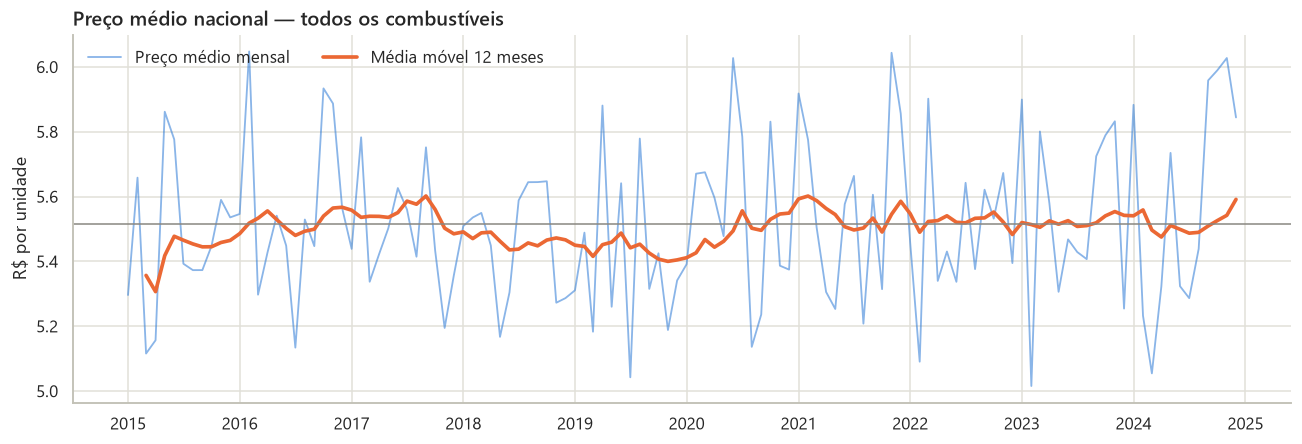

ano,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
mean,5.463,5.564,5.483,5.470,5.404,5.549,5.591,5.480,5.546,5.590
std,1.323,1.415,1.412,1.404,1.393,1.379,1.459,1.464,1.462,1.435


In [15]:
m = D.indicadores_mensais(df)
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(m.data, m.preco_medio, color=AZUL, lw=1.2, alpha=.55, label="Preço médio mensal")
ax.plot(m.data, m.media_movel_12m, color=LARANJA, lw=2.4, label="Média móvel 12 meses")
ax.axhline(m.preco_medio.mean(), color=CINZA, lw=1)
ax.set(title="Preço médio nacional — todos os combustíveis", ylabel="R$ por unidade", xlabel="")
ax.legend(frameon=False, loc="upper left", ncol=2)
fig.tight_layout(); salvar(fig, "01_evolucao_temporal.png"); plt.show()

df.groupby("ano").preco_medio.agg(["mean", "std"]).T

**Interpretação:** a série oscila bastante mês a mês, mas a média móvel de 12 meses é praticamente
plana em torno de R$ 5,50. A média anual varia menos de 4% entre o ano mais barato e o mais caro —
**não há tendência de longo prazo**.

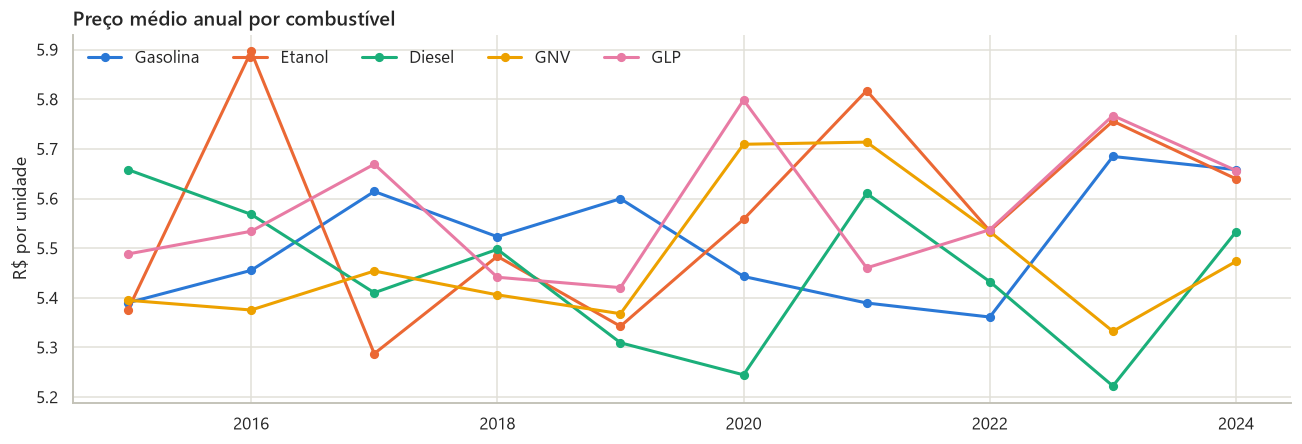

In [16]:
anual = df.groupby(["ano", "combustivel"], observed=True).preco_medio.mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 4.2))
for comb, g in anual.groupby("combustivel", observed=True):
    ax.plot(g.ano, g.preco_medio, marker="o", ms=5, lw=2, color=CORES[comb], label=comb)
ax.set(title="Preço médio anual por combustível", ylabel="R$ por unidade", xlabel="")
ax.legend(frameon=False, ncol=5, loc="upper left")
fig.tight_layout(); salvar(fig, "02_linha_combustiveis.png"); plt.show()

As linhas se cruzam o tempo todo: nenhum combustível é sistematicamente mais caro.

### 8.2 Heatmap mensal

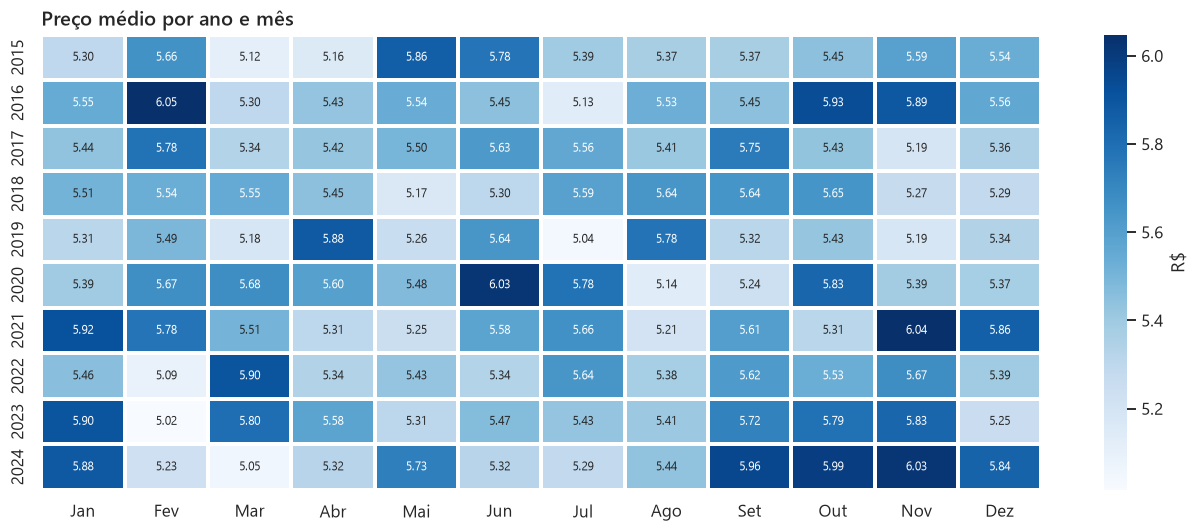

In [17]:
tab = df.pivot_table(index="ano", columns="mes", values="preco_medio", aggfunc="mean")
tab.columns = D.NOMES_MESES
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(tab, cmap="Blues", annot=True, fmt=".2f", annot_kws={"size": 8}, linewidths=1.5,
            linecolor="white", cbar_kws={"label": "R$"}, ax=ax)
ax.set(title="Preço médio por ano e mês", xlabel="", ylabel="")
fig.tight_layout(); salvar(fig, "05_heatmap_mensal.png"); plt.show()

**Interpretação:** não aparecem faixas verticais (mesmo mês caro em vários anos) nem horizontais
(anos inteiros mais caros). **Não há sazonalidade** perceptível.

### 8.3 Comparação entre estados e regiões

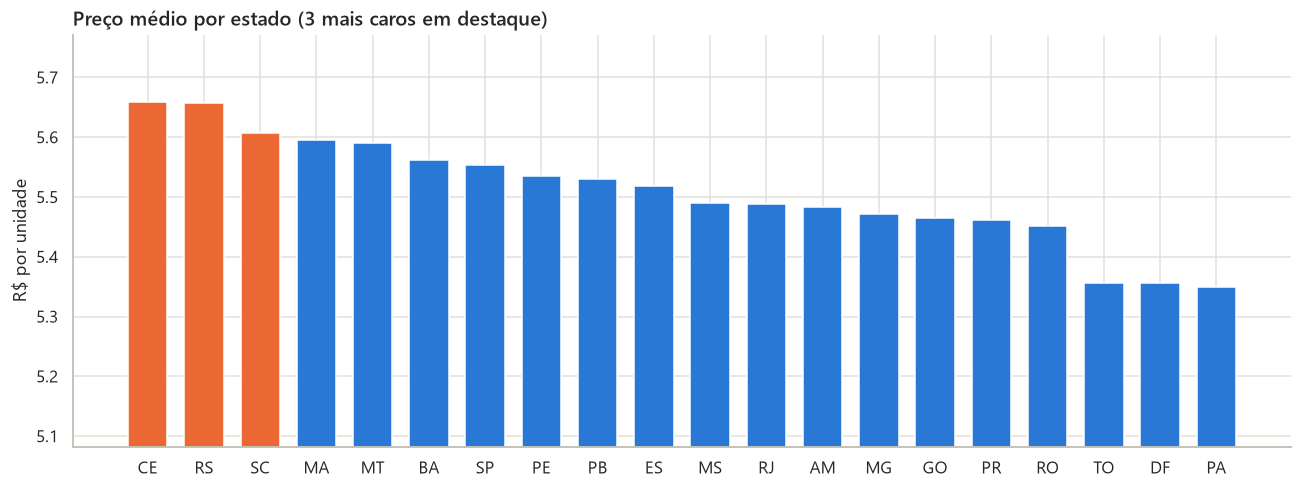

,uf,regiao,preco_medio
2,CE,Nordeste,5.658
16,RS,Sul,5.657
17,SC,Sul,5.607
6,MA,Nordeste,5.596
9,MT,Centro-Oeste,5.590


In [18]:
uf = df.groupby(["uf", "regiao"], observed=True).preco_medio.mean().reset_index().sort_values("preco_medio", ascending=False)
fig, ax = plt.subplots(figsize=(12, 4.6))
cores = [LARANJA if i < 3 else AZUL for i in range(len(uf))]
ax.bar(uf.uf, uf.preco_medio, color=cores, width=.7)
ax.set_ylim(uf.preco_medio.min() * .95, uf.preco_medio.max() * 1.02)
ax.set(title="Preço médio por estado (3 mais caros em destaque)", ylabel="R$ por unidade", xlabel="")
fig.tight_layout(); salvar(fig, "03_barras_estados.png"); plt.show()
uf.head(5)

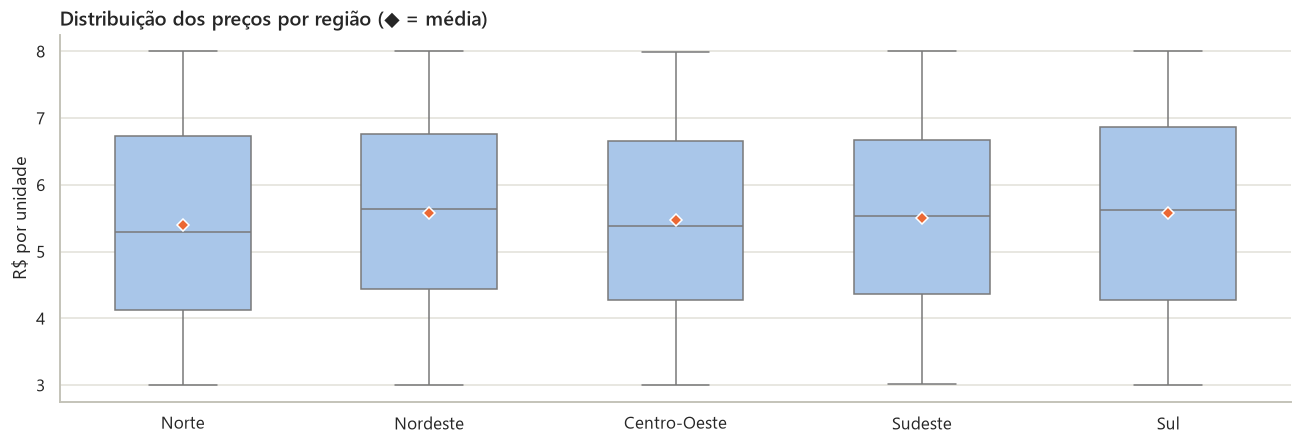

,mean,median,std
regiao,,,
Norte,5.400,5.300,1.444
Nordeste,5.580,5.645,1.422
Centro-Oeste,5.474,5.390,1.411
Sudeste,5.507,5.530,1.370
Sul,5.576,5.625,1.464


In [19]:
fig, ax = plt.subplots(figsize=(12, 4.2))
sns.boxplot(df, x="regiao", y="preco_medio", order=D.ORDEM_REGIOES, color="#9ec5f4", width=.55,
            showmeans=True, meanprops=dict(marker="D", markerfacecolor=LARANJA, markeredgecolor="white"), ax=ax)
ax.set(title="Distribuição dos preços por região (◆ = média)", ylabel="R$ por unidade", xlabel="")
fig.tight_layout(); salvar(fig, "10_regioes_boxplot.png"); plt.show()
df.groupby("regiao", observed=True).preco_medio.agg(["mean", "median", "std"])

**Interpretação:** Ceará, Rio Grande do Sul e Santa Catarina lideram, e o Nordeste é a região mais
cara — mas a diferença entre o primeiro e o último estado é de cerca de 6%, e as caixas das regiões
se sobrepõem quase totalmente. A variação **dentro** de cada região (desvio ≈ R$ 1,46) é muito
maior que a diferença **entre** regiões (≈ R$ 0,18). Diferenças regionais existem, mas **não são
relevantes**.

### 8.4 Comparação entre combustíveis e volatilidade

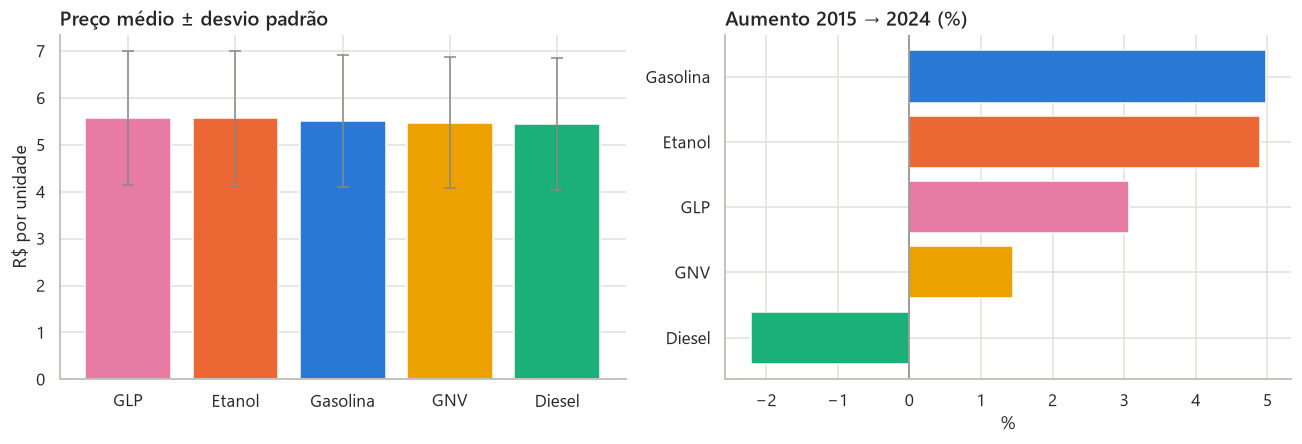

,combustivel,preco_medio,desvio_preco,desvio_variacao,maior_alta,maior_queda,registros,cv_pct,inicio,fim,aumento_pct
0,Gasolina,5.514,1.412,3.845,12.620,-15.610,776,25.609,5.390,5.658,4.975
1,Etanol,5.565,1.432,3.946,12.590,-15.000,766,25.735,5.376,5.640,4.902
2,Diesel,5.446,1.414,3.789,13.280,-11.510,782,25.964,5.658,5.533,-2.210
3,GNV,5.475,1.394,3.986,13.740,-11.150,815,25.462,5.395,5.473,1.451
4,GLP,5.574,1.424,3.809,14.730,-10.530,798,25.541,5.488,5.656,3.064


In [20]:
vol = D.volatilidade_por(df, "combustivel")
aum = D.aumento_periodo(df)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
v = vol.sort_values("preco_medio", ascending=False)
axes[0].bar(v.combustivel.astype(str), v.preco_medio, yerr=v.desvio_preco, capsize=4,
            color=[CORES[str(c)] for c in v.combustivel], error_kw=dict(ecolor=CINZA, lw=1))
axes[0].set(title="Preço médio ± desvio padrão", ylabel="R$ por unidade")
a = aum.sort_values("aumento_pct")
axes[1].barh(a.combustivel.astype(str), a.aumento_pct, color=[CORES[str(c)] for c in a.combustivel])
axes[1].axvline(0, color=CINZA, lw=1)
axes[1].set(title="Aumento 2015 → 2024 (%)", xlabel="%")
fig.tight_layout(); salvar(fig, "04_barras_combustivel.png"); plt.show()
pd.merge(vol, aum, on="combustivel")

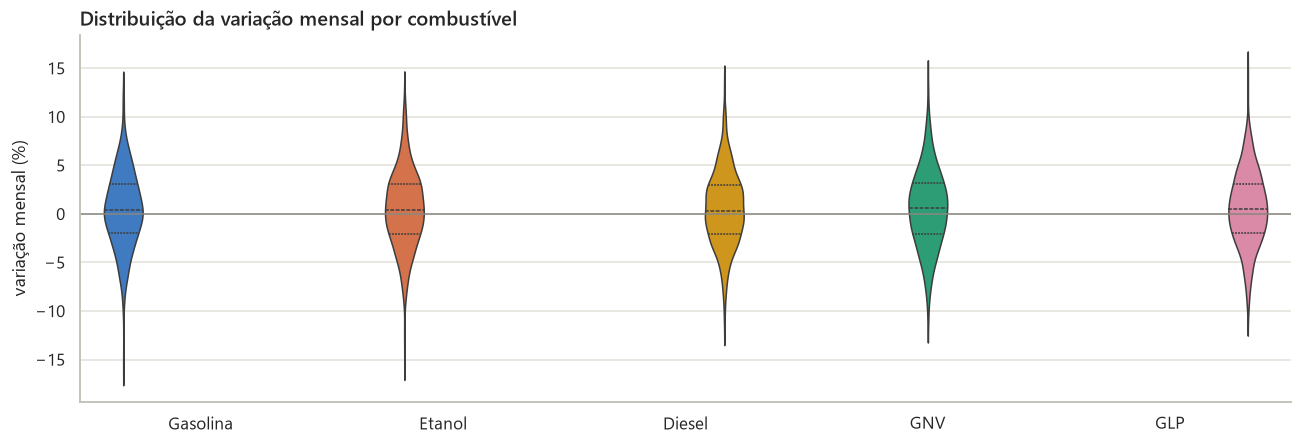

In [21]:
fig, ax = plt.subplots(figsize=(12, 4.2))
sns.violinplot(df, x="combustivel", y="variacao_mensal", hue="combustivel", palette=CORES,
               order=D.ORDEM_COMBUSTIVEIS, inner="quart", linewidth=1, legend=False, ax=ax)
ax.axhline(0, color=CINZA, lw=1)
ax.set(title="Distribuição da variação mensal por combustível", ylabel="variação mensal (%)", xlabel="")
fig.tight_layout(); salvar(fig, "09_volatilidade.png"); plt.show()

**Interpretação:** o GLP e o etanol têm os maiores preços médios e gasolina/etanol o maior aumento
entre 2015 e 2024 (~5%); o diesel foi o único a cair. Porém os desvios padrão se sobrepõem e as
distribuições de variação mensal são praticamente idênticas (simétricas, entre −15% e +15%).
A volatilidade é **alta, mas igual para todos os combustíveis** (desvio ≈ 4 p.p.).

### 8.5 Períodos críticos

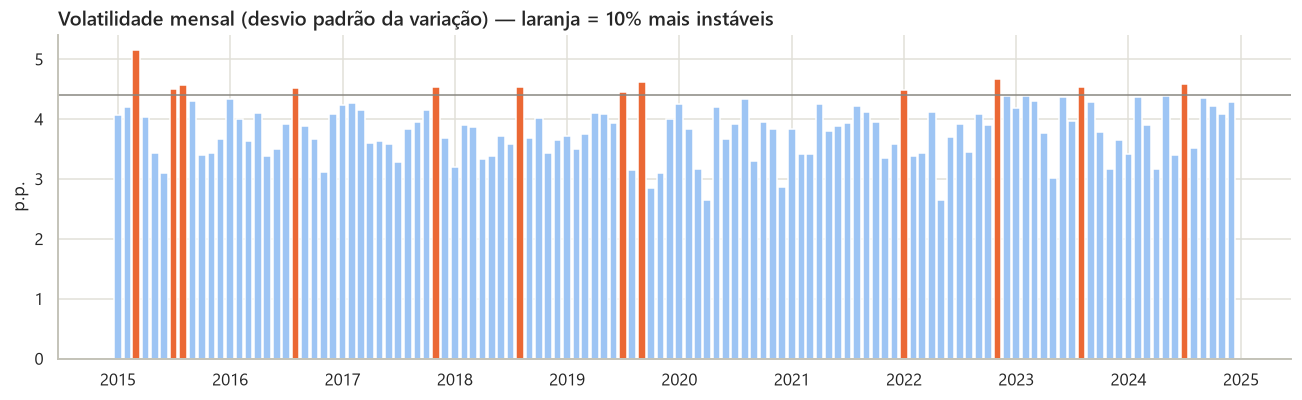

,data,volatilidade,variacao_media,pct_critico
2,2015-03-01,5.152,1.129,34.375
94,2022-11-01,4.670,0.216,20.588
56,2019-09-01,4.625,1.469,15.152
114,2024-07-01,4.586,-0.033,25.714
7,2015-08-01,4.570,1.269,20.588


In [22]:
lim = m.volatilidade.quantile(.9)
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.bar(m.data, m.volatilidade, width=25, color=[LARANJA if v >= lim else "#9ec5f4" for v in m.volatilidade])
ax.axhline(lim, color=CINZA, lw=1)
ax.set(title="Volatilidade mensal (desvio padrão da variação) — laranja = 10% mais instáveis",
       ylabel="p.p.", xlabel="")
fig.tight_layout(); salvar(fig, "12_periodos_criticos.png"); plt.show()
m.nlargest(5, "volatilidade")[["data", "volatilidade", "variacao_media", "pct_critico"]]

**Interpretação:** os meses mais instáveis (mar/2015, nov/2022, set/2019, jul/2024…) aparecem
espalhados pela década, sem formar um período de crise prolongado.

### 8.6 Relação com inflação e petróleo (correlação estatística)

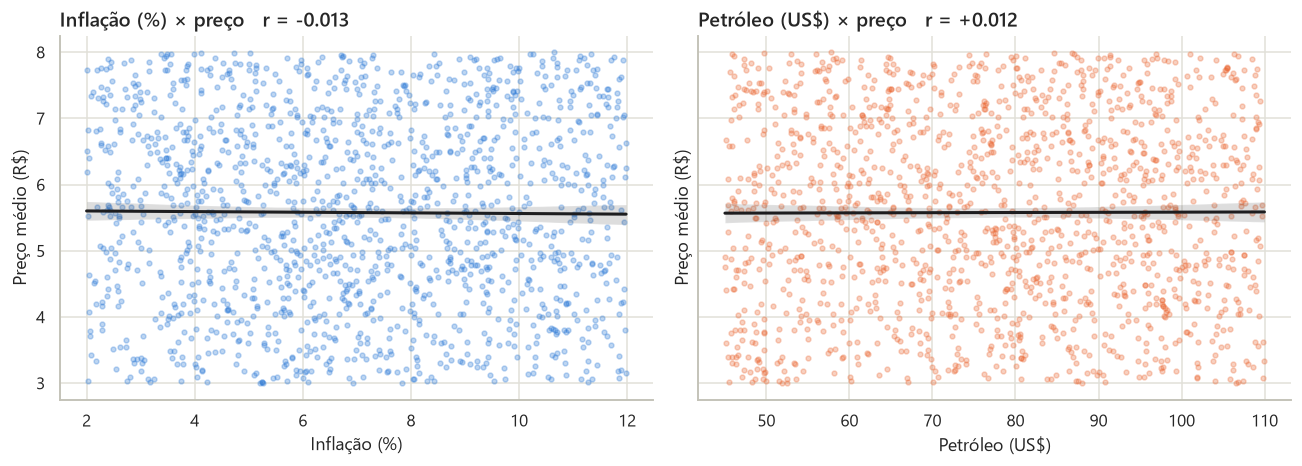

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
amostra = df.sample(1500, random_state=42)
for ax, col, cor, rot in [(axes[0], "inflacao", AZUL, "Inflação (%)"),
                          (axes[1], "cotacao_petroleo", LARANJA, "Petróleo (US$)")]:
    sns.regplot(amostra, x=col, y="preco_medio", ax=ax, color=cor,
                scatter_kws=dict(s=10, alpha=.3), line_kws=dict(color="#1d1d1f", lw=2))
    r = df[col].corr(df.preco_medio)
    ax.set(title=f"{rot} × preço   r = {r:+.3f}", xlabel=rot, ylabel="Preço médio (R$)")
fig.tight_layout(); salvar(fig, "06_dispersao_inflacao.png"); plt.show()

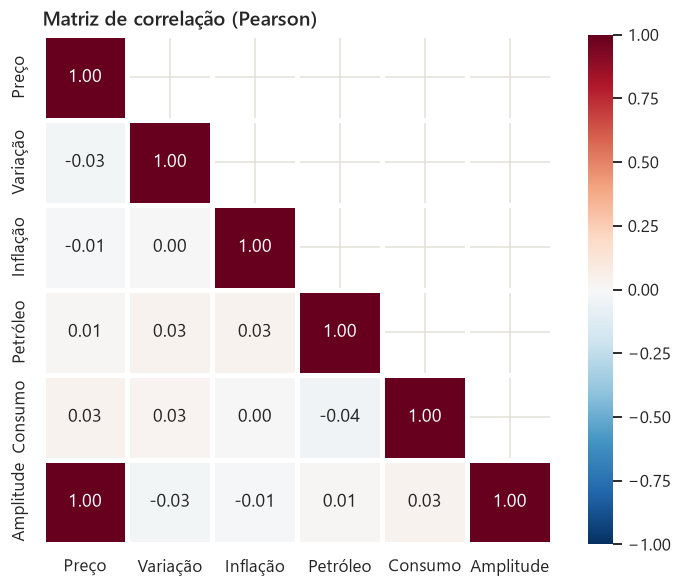

Limiar de significância aproximado (95%): |r| > 0.032
Spearman preço × inflação: -0.0131
Spearman preço × petróleo: 0.0116


In [24]:
cols = {"preco_medio": "Preço", "variacao_mensal": "Variação", "inflacao": "Inflação",
        "cotacao_petroleo": "Petróleo", "consumo_estimado": "Consumo", "amplitude": "Amplitude"}
corr = df[list(cols)].rename(columns=cols).corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, bool), 1), cmap="RdBu_r", vmin=-1, vmax=1,
            annot=True, fmt=".2f", square=True, linewidths=2, linecolor="white", ax=ax)
ax.set_title("Matriz de correlação (Pearson)")
fig.tight_layout(); salvar(fig, "07_matriz_correlacao.png"); plt.show()

limiar = 2 / np.sqrt(len(df))
print(f"Limiar de significância aproximado (95%): |r| > {limiar:.3f}")
print("Spearman preço × inflação:", round(df.preco_medio.rank().corr(df.inflacao.rank()), 4))
print("Spearman preço × petróleo:", round(df.preco_medio.rank().corr(df.cotacao_petroleo.rank()), 4))

**Interpretação:** todas as correlações com o preço ficam abaixo do limiar de significância
(|r| < 0,03). A única relação forte é preço × amplitude, que é estrutural (a amplitude é
proporcional ao preço). Pearson e Spearman concordam — não há relação não linear escondida.
**Nesta base, inflação e petróleo não explicam o preço dos combustíveis.**

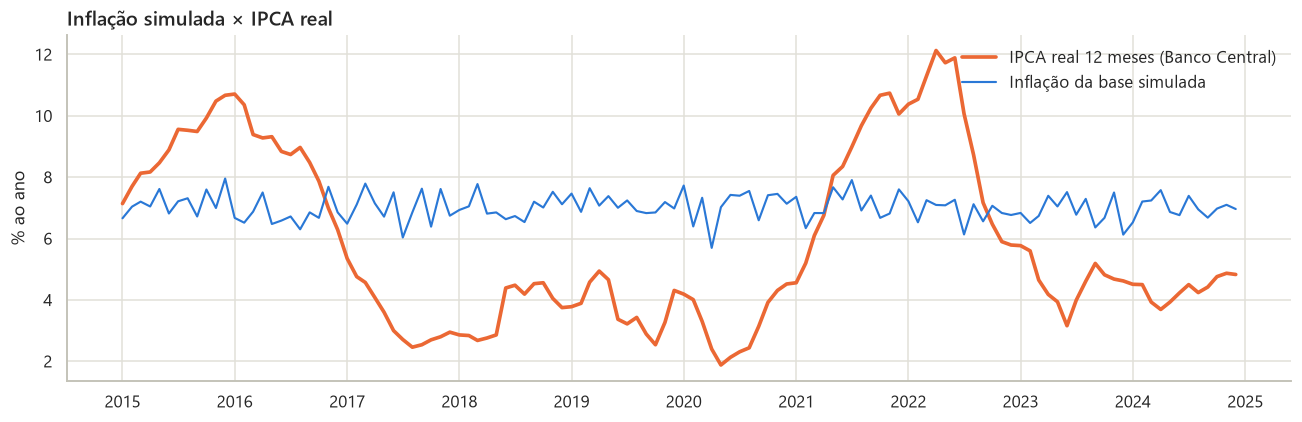

Correlação inflação simulada × IPCA real: -0.001


In [25]:
mm = m.merge(ipca, on="data", how="left")
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mm.data, mm.ipca_12m, color=LARANJA, lw=2.4, label="IPCA real 12 meses (Banco Central)")
ax.plot(mm.data, mm.inflacao, color=AZUL, lw=1.4, label="Inflação da base simulada")
ax.set(title="Inflação simulada × IPCA real", ylabel="% ao ano", xlabel="")
ax.legend(frameon=False, loc="upper right", ncol=1)
fig.tight_layout(); salvar(fig, "08_ipca_real_vs_simulado.png"); plt.show()
print("Correlação inflação simulada × IPCA real:", round(mm.inflacao.corr(mm.ipca_12m), 3))

**Interpretação:** o IPCA real mostra os ciclos da economia brasileira — alta em 2015–2016,
mínima em 2017–2020 e o pico de 2022 (> 12%), puxado justamente pelos combustíveis. A inflação
simulada oscila aleatoriamente em torno de 7%, sem relação com o IPCA real. A integração com a
API confirma que a base **não reproduz a dinâmica macroeconômica**.

## 9. Interpretação dos resultados

| Pergunta | Resposta |
|---|---|
| Estados mais caros? | Ceará, Rio Grande do Sul e Santa Catarina — mas só ~6% acima do mais barato (Pará). |
| Maior aumento? | Gasolina e etanol (~+5% entre 2015 e 2024); diesel caiu (~−2%). |
| Diferenças regionais relevantes? | Não: Nordeste é a mais cara, mas a diferença entre regiões é muito menor que a variação interna. |
| Períodos de instabilidade? | Meses isolados (mar/2015, nov/2022…), sem crise prolongada. |
| Evolução no tempo? | Estável em torno de R$ 5,50, com muito ruído mensal e sem tendência. |
| Relação com inflação? | Nenhuma (r ≈ 0), nem com o petróleo. |
| Maior volatilidade? | GNV e etanol, por margem mínima; todos oscilam ~±4 p.p. por mês. |

A leitura econômica mais importante é a **ausência de padrão**: na realidade, combustíveis
acompanham petróleo, câmbio e ICMS. A base simulada gera essas variáveis de forma independente,
então rankings e "aumentos" são frágeis — mudam conforme o recorte. Reconhecer isso evita
conclusões falsas.

## 10. Conclusão

- O tratamento revelou problemas reais de qualidade: **503 duplicatas de chave** (consolidadas),
  **`nivel_preco` incoerente** com o preço (criada faixa recalculada), **indicadores macro
  inconsistentes** dentro do mês e **amostragem desigual** entre estados.
- Os KPIs e comparações mostram diferenças pequenas entre estados, regiões e combustíveis, e
  nenhuma tendência temporal ou sazonal.
- Os testes de correlação e a comparação com o **IPCA real (API do Banco Central)** mostram que a
  base não tem relação com variáveis macroeconômicas.
- O pipeline construído (limpeza → atributos → SQLite → dashboard) é reaproveitável: aplicado aos
  dados abertos da **ANP**, permitiria investigar os efeitos reais de petróleo, câmbio e ICMS.

O dashboard interativo (`app.py`) permite explorar todos esses resultados com filtros por ano,
mês, região, estado, combustível e nível de preço.